# Run a Batch Experiment for Several Values of xi

### Setup

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from msean import load_config
from msean.measurements.batch import batch_experiment
from msean.measurements.properties import PropertyEnum

Load global configuration from file <b>configs/default.yaml</b>.

In [2]:
# Load configuration file
root = Path.cwd().parents[0] # go up from notebooks/ to project root
cfg = load_config(root / "configs" / "default.yaml")
runs_dir = root / "runs"

Intialize random number generator for experiment reproducibility.

In [3]:
rng = np.random.default_rng(cfg.seed)

### Run Batch Experiment
Here, we experiment with parameter xi of the connection function, for values in the range [1, 5], with a step value of 1. We store values for the following properties: average degree, density, clustering, degree distribution.

In [4]:
results, paths = batch_experiment(
        cfg=cfg,
        parent_dir=runs_dir,
        rng=rng,
        param_name="connection.xi",
        param_range=(1, 5, 1),
        properties=[
            PropertyEnum.AVERAGE_DEGREE,
            PropertyEnum.DENSITY,
            PropertyEnum.CLUSTERING,
            PropertyEnum.DEGREE_DISTRIBUTION,
        ],
    )

### Property Analysis

In [5]:
xis = sorted(results.keys())

Aggregate plot example for a global property (average degree):

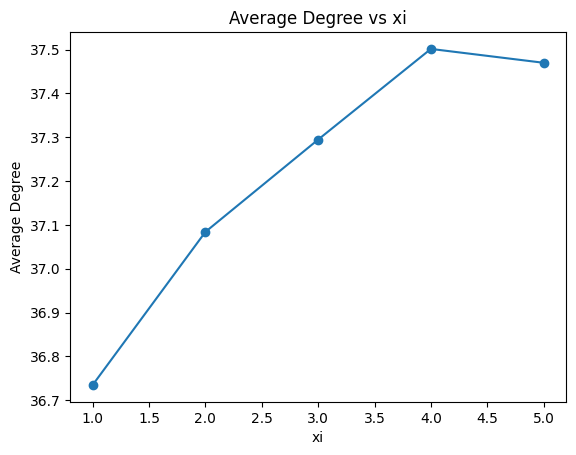

In [6]:
avg_degs = [results[xi][PropertyEnum.AVERAGE_DEGREE] for xi in xis]

fig = plt.figure()

plt.plot(xis, avg_degs, marker="o")
plt.title("Average Degree vs xi")
plt.xlabel("xi")
plt.ylabel("Average Degree")

# Save in "plots" folder of the batch experiment directory
plt.savefig(paths["plots"] / "average_degree_vs_xi.png", bbox_inches="tight")
plt.show()

Individual plot example for a distribution property (degree distribution):

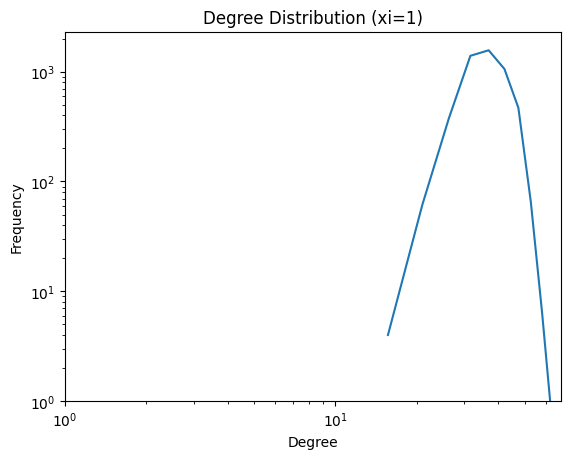

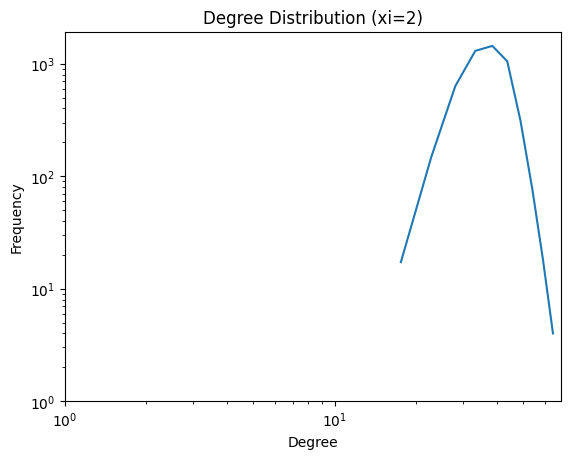

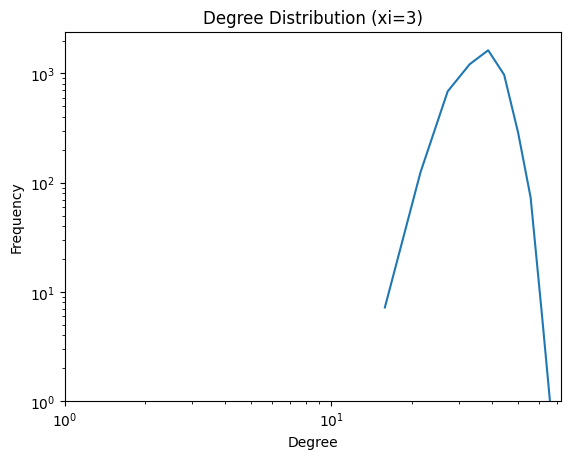

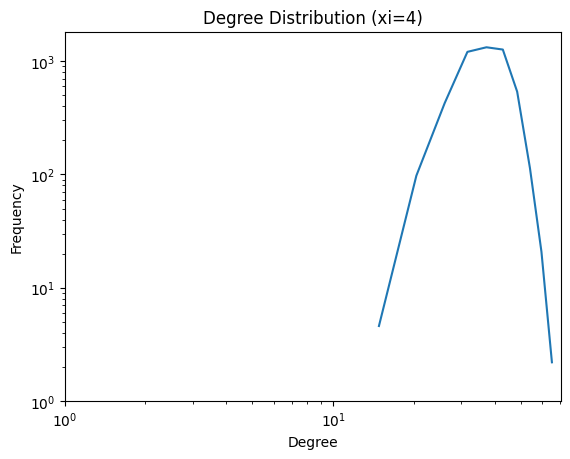

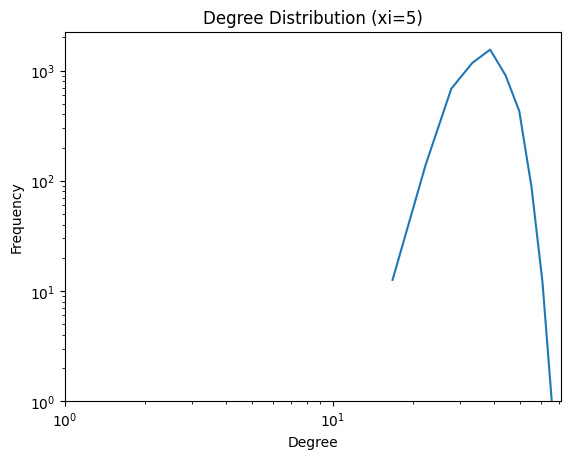

In [7]:
for xi in xis:
    deg_dist = results[xi][PropertyEnum.DEGREE_DISTRIBUTION]

    k = deg_dist[:, 0]
    freq = deg_dist[:, 1]

    freqs, bin_edges = np.histogram(k, weights=freq)
    bin_mids = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    fig = plt.figure()

    plt.plot(bin_mids, freqs)
    plt.title(f"Degree Distribution (xi={xi})")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(1, plt.xlim()[1])
    plt.ylim(1, plt.ylim()[1])

    # Save in "plots" folder of the individual run
    plt.savefig(paths["batch_dir"] / f"xi_{xi}" / "plots" / f"degree_distribution_xi_{xi}.png", bbox_inches="tight")
    plt.show()

Aggregate plot example for a distribution property (degree distribution):

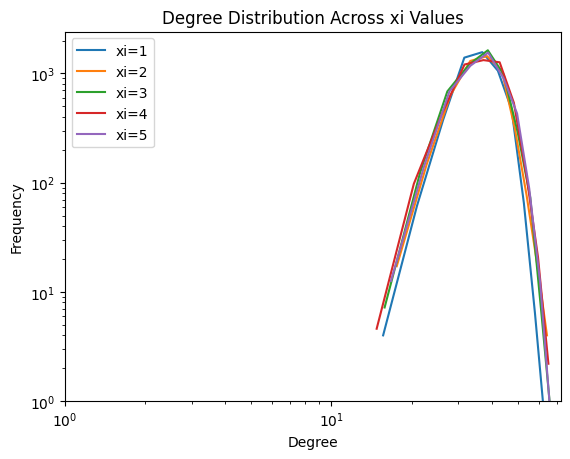

In [8]:
fig = plt.figure()

for xi in xis:
    deg_dist = results[xi][PropertyEnum.DEGREE_DISTRIBUTION]

    k = deg_dist[:, 0]
    freq = deg_dist[:, 1]

    freqs, bin_edges = np.histogram(k, weights=freq)
    bin_mids = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.plot(bin_mids, freqs, label=f"xi={xi}")

plt.title("Degree Distribution Across xi Values")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xscale("log")
plt.yscale("log")
plt.xlim(1, plt.xlim()[1])
plt.ylim(1, plt.ylim()[1])
plt.legend()

# Save in "plots" folder of the batch experiment directory
plt.savefig(paths["plots"] / "degree_distribution_by_xi.png", bbox_inches="tight")
plt.show()